# L1 vs L2 Regularization : A Geometric Explanation

## The Central Question

Ridge and Lasso both add a penalty to the OLS loss function to constrain
the coefficients. The only difference is the shape of that penalty :

$$\text{Ridge :} \quad \hat{\beta} = \arg\min_{\beta} \left[ \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \lambda \|\beta\|^2 \right]$$

$$\text{Lasso :} \quad \hat{\beta} = \arg\min_{\beta} \left[ \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 + \lambda |\beta| \right]$$

Where $\|\beta\|_2^2 = \sum_j \beta_j^2$ and $\|\beta\|_1 = \sum_j |\beta_j|$.

This seemingly small difference has a radical consequence : **Lasso can
set coefficients exactly to zero, Ridge cannot**. Why ?

The answer is purely geometric.

## Table of Contents

1. [The Optimization Problem as Geometry](#1-the-optimization-problem-as-geometry)
2. [Regularization as Constrained Optimization](#2-regularization-as-constrained-optimization)
3. [The Constraint Regions : L1 vs L2](#3-the-constraint-regions--l1-vs-l2)
4. [Why Lasso Produces Exact Zeros](#4-why-lasso-produces-exact-zeros)
5. [The Role of λ : Shrinking the Constraint Region](#5-the-role-of-λ--shrinking-the-constraint-region)
6. [Empirical Verification on California Housing](#6-empirical-verification-on-california-housing)
7. [Practical Implications](#7-practical-implications)
8. [Conclusion](#8-conclusion)

> All models are implemented from scratch using NumPy only.
> No machine learning library is used for estimation.

## 1. The Optimization Problem as Geometry

In OLS, we minimize the Mean Squared Error freely :

$$\min_{\beta} \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

The solution is the point in the space of coefficients $(\beta_1, \beta_2)$
that minimizes this function. Geometrically, this function forms a family
of **ellipses** centered on the OLS solution $\hat{\beta}_{OLS}$ : each
ellipse represents all combinations of $(\beta_1, \beta_2)$ that give
the same MSE value.

The further an ellipse is from the center, the higher the MSE. The OLS
solution sits at the center of the smallest ellipse, where the MSE is
minimized.

When we add a regularization penalty, we are no longer free to reach
that center. We must stay inside a **constraint region** whose shape
depends on whether we use L1 or L2 regularization.

The regularized solution is therefore the point where the smallest
possible MSE ellipse **touches** the constraint region.

## 2. Regularization as Constrained Optimization

Minimizing the Ridge or Lasso loss function is equivalent to solving a
**constrained optimization problem** :

$$\text{Ridge :} \quad \min_{\beta} \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 \quad \text{subject to} \quad \|\beta\|^2 \leq t$$

$$\text{Lasso :} \quad \min_{\beta} \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 \quad \text{subject to} \quad |\beta| \leq t$$

Where $t$ is a budget that controls how large the coefficients can be.
A smaller $t$ means stronger regularization, which corresponds to a
larger $\lambda$ in the penalized formulation.

**The geometric interpretation :** the constraint defines a region in
the space of coefficients $(\beta_1, \beta_2)$ within which the solution
must lie. The unconstrained OLS solution minimizes the MSE freely. The
regularized solution is the point inside the constraint region that is
closest to the OLS solution, in terms of MSE.

This is where geometry becomes decisive : the **shape** of the constraint
region determines whether exact zeros are possible or not.

## 3. The Constraint Regions : L1 vs L2

The two regularization methods define fundamentally different constraint
regions in the space of coefficients $(\beta_1, \beta_2)$ :

**L2 constraint (Ridge) :** $\beta_1^2 + \beta_2^2 \leq t$

This is a **circle** (or sphere in higher dimensions). Its boundary is
perfectly smooth, with no corners or edges anywhere.

**L1 constraint (Lasso) :** $|\beta_1| + |\beta_2| \leq t$

This is a **diamond** (or cross-polytope in higher dimensions). Its
boundary has **corners located exactly on the axes**, where one
coefficient is zero.

This geometric difference is the entire reason why Lasso produces sparse
solutions and Ridge does not. We now visualize both regions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 130

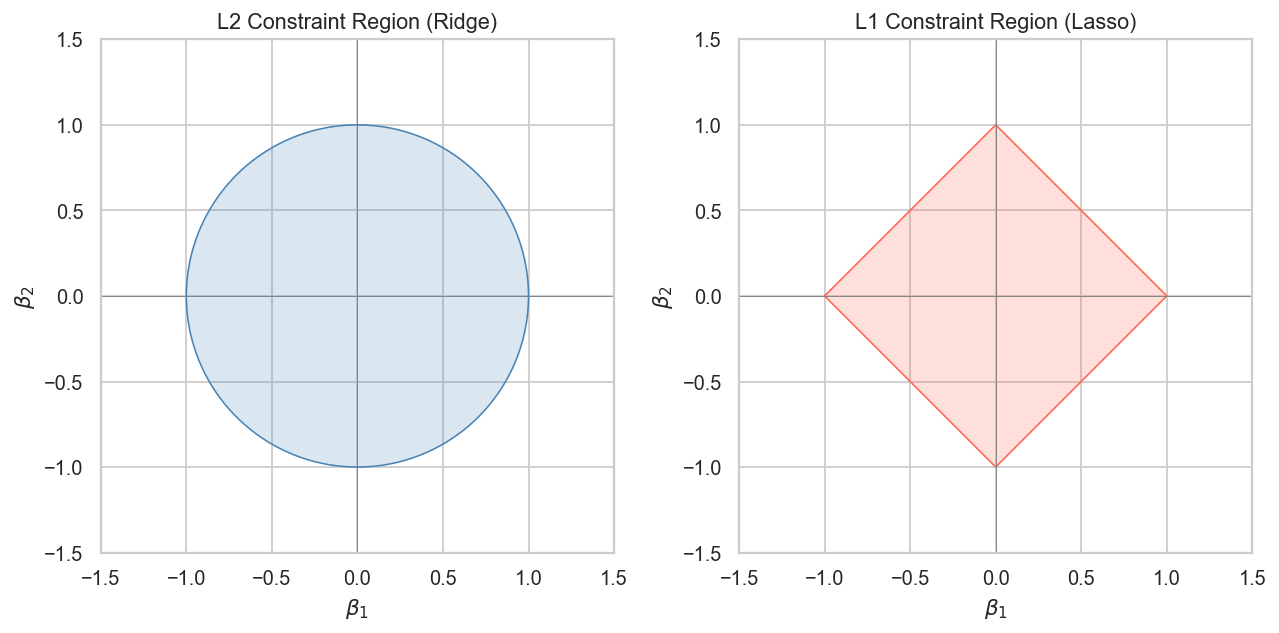

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

t = 1.0
theta = np.linspace(0, 2 * np.pi, 300)

axes[0].fill(np.cos(theta) * t, np.sin(theta) * t,
             alpha=0.2, color="steelblue")
axes[0].plot(np.cos(theta) * t, np.sin(theta) * t,
             color="steelblue", linewidth=0.8)
axes[0].axhline(0, color="gray", linewidth=0.5)
axes[0].axvline(0, color="gray", linewidth=0.5)
axes[0].set_xlim(-1.5, 1.5)
axes[0].set_ylim(-1.5, 1.5)
axes[0].set_xlabel(r"$\beta_1$")
axes[0].set_ylabel(r"$\beta_2$")
axes[0].set_title("L2 Constraint Region (Ridge)")
axes[0].set_aspect("equal")

diamond_x = [t, 0, -t, 0, t]
diamond_y = [0, t, 0, -t, 0]
axes[1].fill(diamond_x, diamond_y, alpha=0.2, color="tomato")
axes[1].plot(diamond_x, diamond_y, color="tomato", linewidth=0.8)
axes[1].axhline(0, color="gray", linewidth=0.5)
axes[1].axvline(0, color="gray", linewidth=0.5)
axes[1].set_xlim(-1.5, 1.5)
axes[1].set_ylim(-1.5, 1.5)
axes[1].set_xlabel(r"$\beta_1$")
axes[1].set_ylabel(r"$\beta_2$")
axes[1].set_title("L1 Constraint Region (Lasso)")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.savefig("images/constraint_regions.png", dpi=130, bbox_inches="tight")
plt.show()

## 4. Why Lasso Produces Exact Zeros

The regularized solution is the point where the smallest possible MSE
ellipse **touches** the constraint region. This is the key geometric
insight.

**With Ridge (L2) :** the constraint region is a smooth circle. The MSE
ellipses are also smooth curves. When a smooth curve touches another
smooth curve, the contact point can be anywhere on the boundary. The
probability of touching exactly on an axis (where one coefficient is
zero) is essentially zero.

**With Lasso (L1) :** the constraint region is a diamond with corners
located exactly on the axes. The MSE ellipses are smooth, so when they
expand outward from the OLS solution, they are very likely to first
contact the diamond at one of its corners, where one coefficient is
exactly zero.

This is not a coincidence or a numerical artifact. It is a direct
consequence of the geometry : **corners attract the solution**.

We now visualize this by plotting MSE ellipses together with both
constraint regions, and showing where the optimal solution lands.

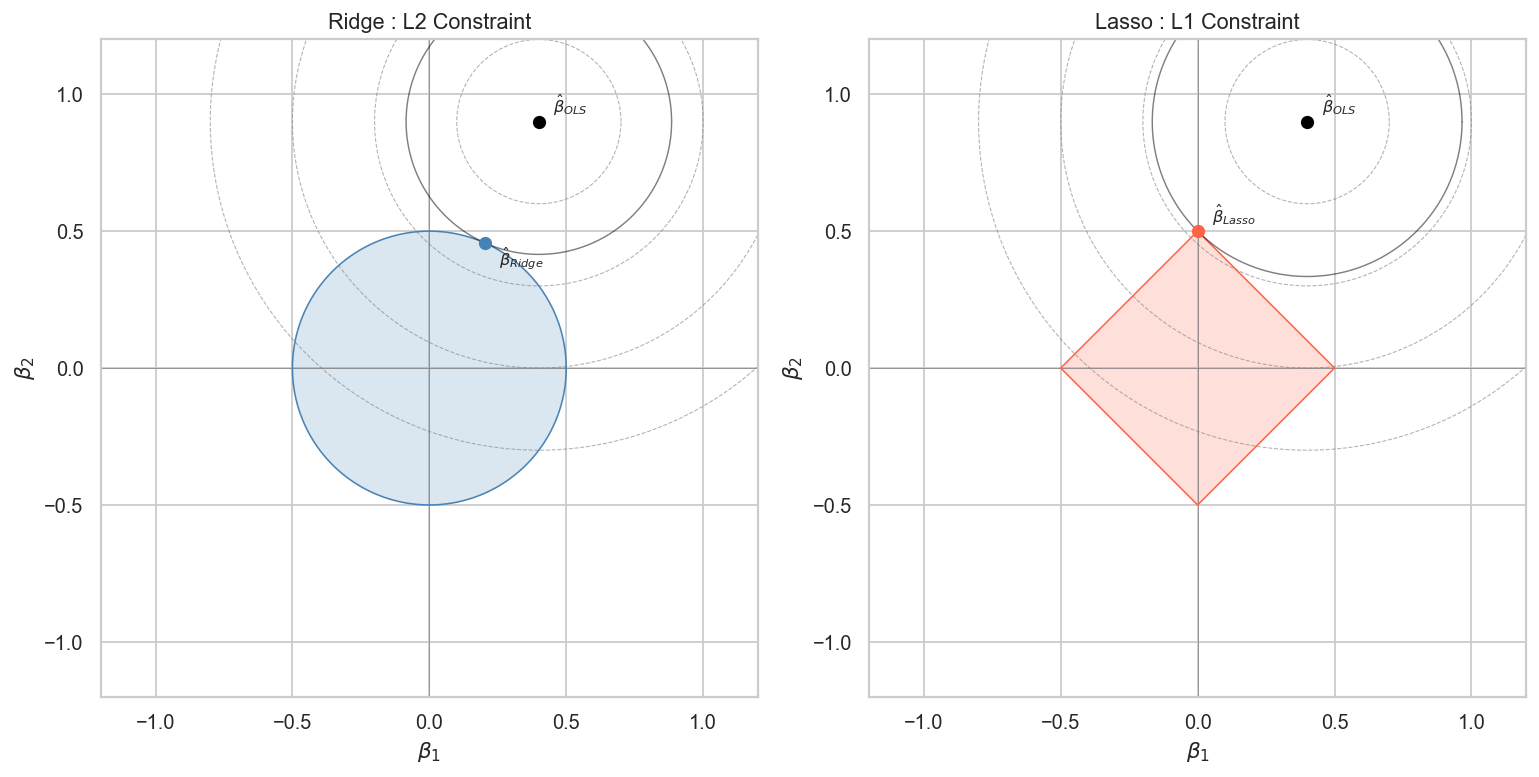

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

beta_ols = np.array([0.4, 0.9])
t = 0.5

# Ridge solution : L2 projection
norm = np.linalg.norm(beta_ols)
beta_ridge = beta_ols * t / norm

# Lasso solution : closest point on L1 ball to beta_ols
# Force landing on a corner by zeroing the smaller coefficient
if abs(beta_ols[0]) < abs(beta_ols[1]):
    beta_lasso = np.array([0.0, np.sign(beta_ols[1]) * t])
else:
    beta_lasso = np.array([np.sign(beta_ols[0]) * t, 0.0])

# MSE level curves : isotropic circles centered on beta_ols
def mse_ellipse(center, levels, n=300):
    theta = np.linspace(0, 2 * np.pi, n)
    ellipses = []
    for level in levels:
        x = center[0] + level * np.cos(theta)
        y = center[1] + level * np.sin(theta)
        ellipses.append((x, y))
    return ellipses

levels = [0.3, 0.6, 0.9, 1.2]
ellipses = mse_ellipse(beta_ols, levels)
theta = np.linspace(0, 2 * np.pi, 300)

for ax, title in zip(axes, ["Ridge : L2 Constraint", "Lasso : L1 Constraint"]):
    for x, y in ellipses:
        ax.plot(x, y, color="gray", linewidth=0.6, linestyle="--", alpha=0.6)
    ax.scatter(*beta_ols, color="black", zorder=5, s=40)
    ax.annotate(r"$\hat{\beta}_{OLS}$", beta_ols,
                textcoords="offset points", xytext=(8, 5), fontsize=9)
    ax.axhline(0, color="gray", linewidth=0.4)
    ax.axvline(0, color="gray", linewidth=0.4)
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_xlabel(r"$\beta_1$")
    ax.set_ylabel(r"$\beta_2$")
    ax.set_aspect("equal")
    ax.set_title(title)

# Left : L2 constraint region
axes[0].fill(np.cos(theta) * t, np.sin(theta) * t, alpha=0.2, color="steelblue")
axes[0].plot(np.cos(theta) * t, np.sin(theta) * t, color="steelblue", linewidth=0.8)
axes[0].scatter(*beta_ridge, color="steelblue", zorder=6, s=40)
axes[0].annotate(r"$\hat{\beta}_{Ridge}$", beta_ridge,
                 textcoords="offset points", xytext=(8, -12), fontsize=9)

# Tangent circle touching beta_ridge
radius_r = np.linalg.norm(beta_ridge - beta_ols)
axes[0].plot(beta_ols[0] + radius_r * np.cos(theta),
             beta_ols[1] + radius_r * np.sin(theta),
             color="black", linewidth=0.8, linestyle="-", alpha=0.5)

# Right : L1 constraint region
diamond_x = [t, 0, -t, 0, t]
diamond_y = [0, t, 0, -t, 0]
axes[1].fill(diamond_x, diamond_y, alpha=0.2, color="tomato")
axes[1].plot(diamond_x, diamond_y, color="tomato", linewidth=0.8)
axes[1].scatter(*beta_lasso, color="tomato", zorder=6, s=40)
axes[1].annotate(r"$\hat{\beta}_{Lasso}$", beta_lasso,
                 textcoords="offset points", xytext=(8, 5), fontsize=9)

# Tangent circle touching beta_lasso corner
radius_l = np.linalg.norm(beta_lasso - beta_ols)
axes[1].plot(beta_ols[0] + radius_l * np.cos(theta),
             beta_ols[1] + radius_l * np.sin(theta),
             color="black", linewidth=0.8, linestyle="-", alpha=0.5)

plt.tight_layout()
plt.savefig("images/geometry_solution.png", dpi=130, bbox_inches="tight")
plt.show()

## 5. The Role of λ : Shrinking the Constraint Region

The parameter λ controls the **size** of the constraint region, and
therefore the amount of regularization applied.

- A **large λ** → small constraint region → coefficients forced far
  from β̂_OLS → strong shrinkage
- A **small λ** → large constraint region → β̂_OLS may lie inside it
  → solution approaches OLS

In the constrained formulation, λ maps to the budget t : a larger λ
corresponds to a smaller t. Below, we visualize how the solution
moves as t decreases, for both Ridge and Lasso.

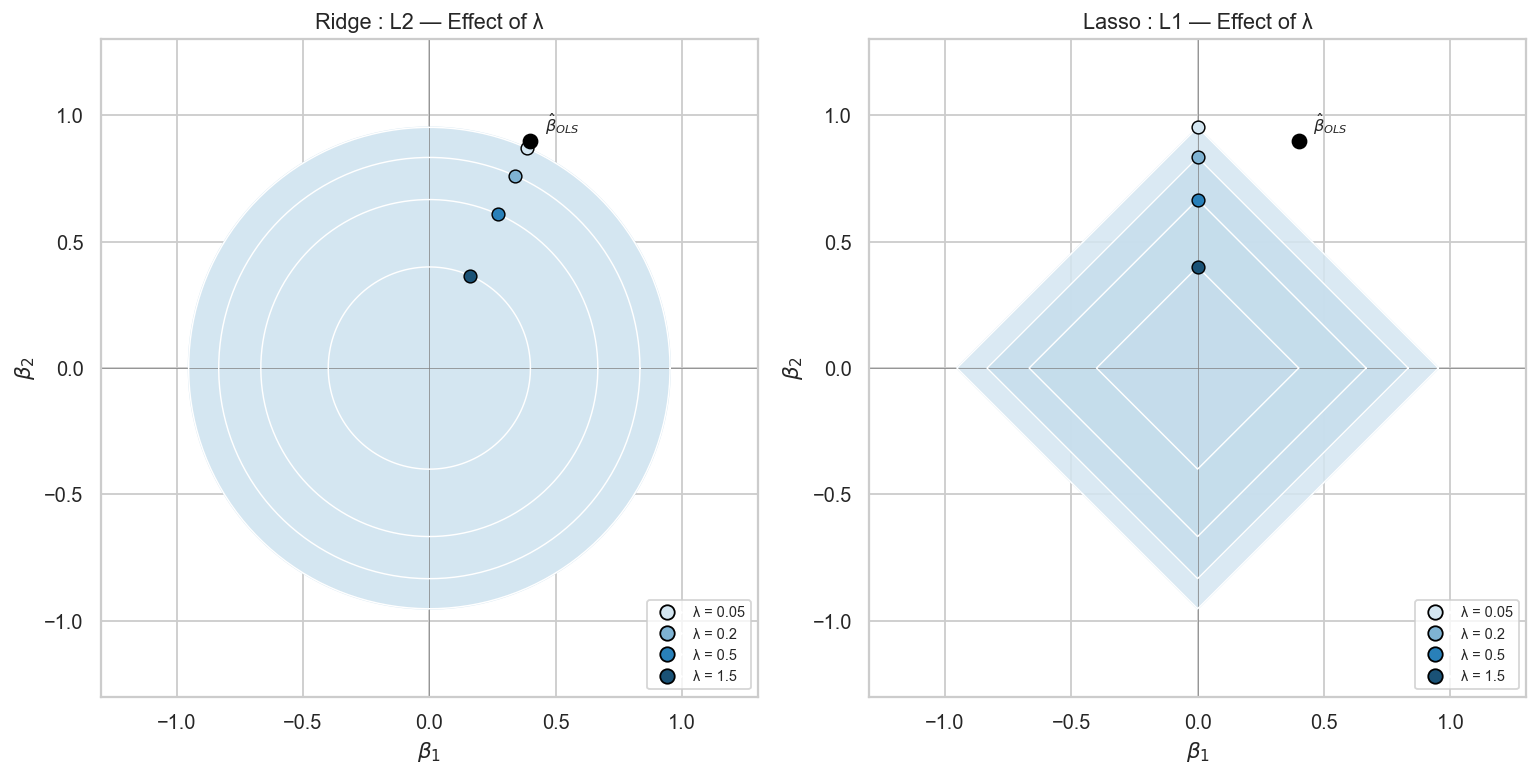

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

beta_ols = np.array([0.4, 0.9])
lambda_values = [1.5, 0.5, 0.2, 0.05]
colors = colors = ["#1a5276", "#2980b9", "#7fb3d3", "#d4e6f1"] 
theta = np.linspace(0, 2 * np.pi, 300)

def lam_to_t(lam):
    return 1 / (1 + lam)

for ax, title, constraint in zip(
    axes,
    ["Ridge : L2 — Effect of λ", "Lasso : L1 — Effect of λ"],
    ["L2", "L1"]
):
    ax.axhline(0, color="gray", linewidth=0.4)
    ax.axvline(0, color="gray", linewidth=0.4)
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-1.3, 1.3)
    ax.set_xlabel(r"$\beta_1$")
    ax.set_ylabel(r"$\beta_2$")
    ax.set_aspect("equal")
    ax.set_title(title)

    for lam, color in zip(lambda_values, colors):
        t = lam_to_t(lam)
        if constraint == "L2":
            ax.fill(np.cos(theta) * t, np.sin(theta) * t,
                    alpha=1.0, color=color)
            ax.plot(np.cos(theta) * t, np.sin(theta) * t,
                    color="white", linewidth=0.8)
            sol = beta_ols * t / np.linalg.norm(beta_ols)
        else:
            dx = [t, 0, -t, 0, t]
            dy = [0, t, 0, -t, 0]
            ax.fill(dx, dy, alpha=0.85, color=color)
            ax.plot(dx, dy, color="white", linewidth=0.8)

            if abs(beta_ols[0]) + abs(beta_ols[1]) <= t:
                sol = beta_ols
            elif abs(beta_ols[0]) < abs(beta_ols[1]):
                sol = np.array([0.0, np.sign(beta_ols[1]) * t])
            else:
                sol = np.array([np.sign(beta_ols[0]) * t, 0.0])

        ax.scatter(*sol, color=color, edgecolors="black",
                   linewidths=0.8, zorder=8, s=50)

    ax.scatter(*beta_ols, color="black", zorder=10, s=60)
    ax.annotate(r"$\hat{\beta}_{OLS}$", beta_ols,
                textcoords="offset points", xytext=(8, 5), fontsize=9)

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=c, markeredgecolor='black',
               markersize=8, label=f"λ = {lam}")
        for lam, c in zip(reversed(lambda_values), reversed(colors))
    ]
    ax.legend(handles=legend_elements, fontsize=8,
              loc="lower right", framealpha=0.8)

plt.tight_layout()
plt.savefig("images/lambda_effect.png", dpi=130, bbox_inches="tight")
plt.show()

## 6. Empirical Verification on California Housing

We now confirm the geometric intuition numerically. Ridge and Lasso
are implemented **from scratch with NumPy only** — no scikit-learn.

**Ridge** has a closed-form solution :

$$\hat{\beta}_{Ridge} = \left(\frac{1}{n}X^T X + \lambda I\right)^{-1} \frac{1}{n}X^T y$$

**Lasso** has no closed form. We solve it via **coordinate descent** :
cycle over each coefficient βⱼ, update it while holding all others
fixed. The analytical update for βⱼ is :

$$\hat{\beta}_j \leftarrow \mathcal{S}\left(\frac{X_j^T r_j}{n},\ \lambda\right) \cdot \frac{n}{\|X_j\|^2}$$

where $r_j = y - X_{-j}\beta_{-j}$ is the partial residual and
$\mathcal{S}(z, \lambda) = \text{sign}(z)\,\max(|z| - \lambda, 0)$
is the **soft-thresholding operator**.

The key prediction : **Lasso will drive some coefficients to exactly
zero, Ridge will not**.

In [11]:
from sklearn.datasets import fetch_california_housing

# Load dataset
data = fetch_california_housing()
X_raw, y = data.data, data.target
feature_names = data.feature_names

# Standardize features to zero mean and unit variance
X_mean = X_raw.mean(axis=0)
X_std  = X_raw.std(axis=0)
X = (X_raw - X_mean) / X_std

# Center y to remove the need for an explicit intercept
y_mean = y.mean()
y_c = y - y_mean
y_std = y_c.std()
y_c = y_c / y_std

n, p = X.shape
print(f"Dataset : {n} observations, {p} features")
print(f"Features : {list(feature_names)}")

Dataset : 20640 observations, 8 features
Features : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


### Ridge Regression : Closed-form solution

$$\hat{\beta}_{Ridge} = \left(\frac{1}{n}X^T X + \lambda I\right)^{-1} \frac{1}{n}X^T y$$

In [12]:
def ridge_scratch(X, y, lam):
    n, p = X.shape
    A = X.T @ X / n + lam * np.eye(p)
    b = X.T @ y / n
    return np.linalg.solve(A, b)

### Lasso Regression : Coordinate Descent

No closed form exists. We cycle over each coefficient and apply
the soft-thresholding operator, holding all others fixed :

$$\hat{\beta}_j \leftarrow \mathcal{S}\!\left(\frac{X_j^T r_j}{n},\ \lambda\right) \cdot \frac{n}{\|X_j\|^2}$$

Warm starting (initializing from the previous solution) accelerates
convergence when sweeping over a grid of $\lambda$ values.

In [ ]:
def soft_threshold(z, lam):
    return np.sign(z) * np.maximum(np.abs(z) - lam, 0.0)

def lasso_cd(X, y, lam, beta_init=None, max_iter=2000, tol=1e-7):
    n, p = X.shape
    beta = beta_init.copy() if beta_init is not None else np.zeros(p)
    Xnorm2 = (X ** 2).sum(axis=0)
    for _ in range(max_iter):
        beta_old = beta.copy()
        for j in range(p):
            r_j = y - X @ beta + X[:, j] * beta[j]  # partial residual
            rho_j = X[:, j] @ r_j / n
            beta[j] = soft_threshold(rho_j, lam) * n / Xnorm2[j]
        if np.max(np.abs(beta - beta_old)) < tol:
            break
    return beta

### Regularization Path : Ridge vs Lasso

We compute the coefficients for a grid of λ values, from large
(strong regularization) to small (close to OLS).
Ridge uses warm starting implicitly (closed form).
Lasso uses warm starting explicitly to speed up convergence.

In [40]:
lambdas = np.logspace(-0.5, -3, 100)

# Ridge path
betas_ridge = np.array([ridge_scratch(X, y_c, lam) for lam in lambdas])

# Lasso path
betas_lasso = np.zeros((len(lambdas), p))
beta_warm = np.zeros(p)
for i, lam in enumerate(lambdas):
    beta_warm = lasso_cd(X, y_c, lam, beta_init=beta_warm)
    betas_lasso[i] = beta_warm

print("Ridge - no exact zero coefficient :", np.sum(betas_ridge[-1] == 0))
print("Lasso - exact zero coefficients at lambda=0.001 :", np.sum(betas_lasso[-1] == 0))

Ridge - no exact zero coefficient : 0
Lasso - exact zero coefficients at lambda=0.001 : 0


In [31]:
for idx in [10, 30, 50, 70]:
    lam = lambdas[idx]
    n_zeros_ridge = np.sum(np.abs(betas_ridge[idx]) < 1e-10)
    n_zeros_lasso = np.sum(betas_lasso[idx] == 0)
    print(f"lam={lam:.4f}  Ridge zeros={n_zeros_ridge}  Lasso zeros={n_zeros_lasso}")

lam=0.1768  Ridge zeros=0  Lasso zeros=7
lam=0.0553  Ridge zeros=0  Lasso zeros=4
lam=0.0173  Ridge zeros=0  Lasso zeros=2
lam=0.0054  Ridge zeros=0  Lasso zeros=1


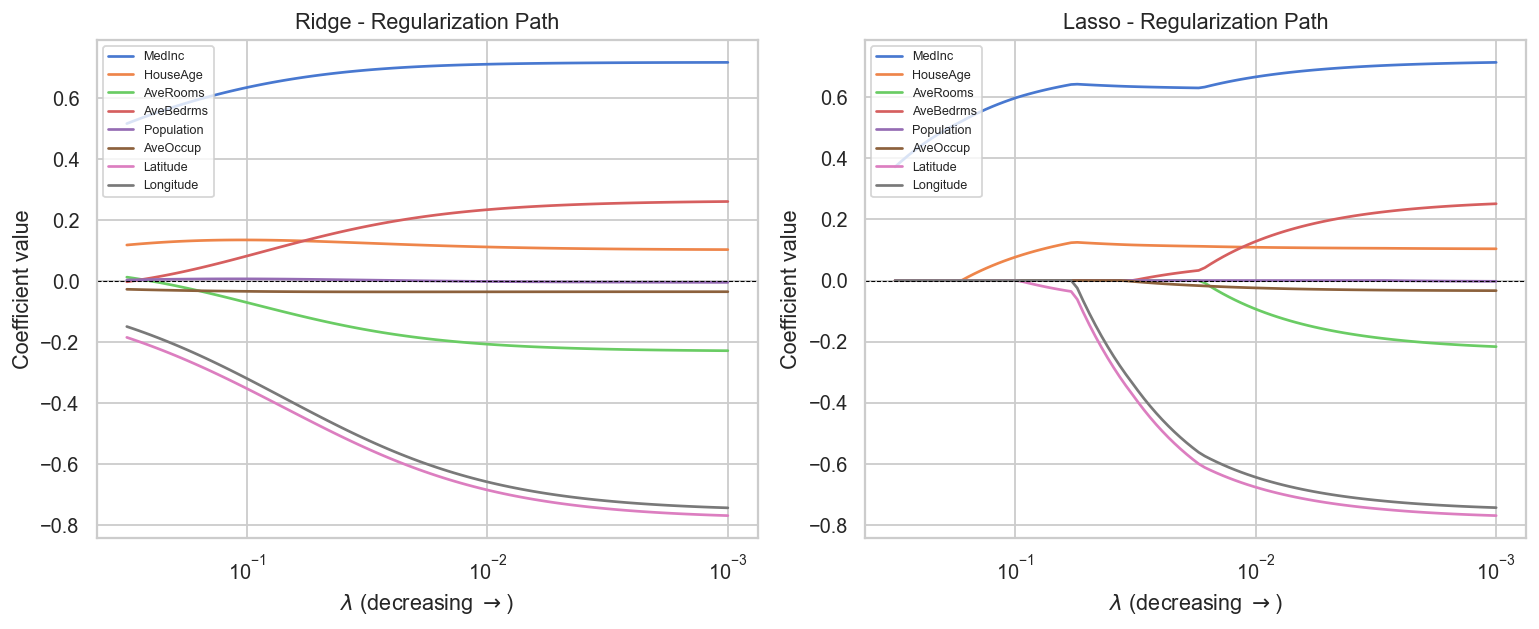

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, betas, title in zip(
    axes,
    [betas_ridge, betas_lasso],
    ["Ridge - Regularization Path", "Lasso - Regularization Path"]
):
    for j in range(p):
        ax.plot(lambdas, betas[:, j], label=feature_names[j])
    ax.axhline(0, color="black", linewidth=0.6, linestyle="--")
    ax.set_xscale("log")
    ax.invert_xaxis()
    ax.set_xlabel(r"$\lambda$ (decreasing $\rightarrow$)")
    ax.set_ylabel("Coefficient value")
    ax.set_title(title)
    ax.legend(fontsize=7, loc="upper left")

plt.tight_layout()
plt.savefig("images/regularization_paths.png", dpi=130, bbox_inches="tight")
plt.show()

In [41]:
print("Lasso - entry lambda per variable::\n")
for j in range(p):
    path_j = betas_lasso[:, j]
    nonzero_idx = np.where(path_j != 0)[0]
    if len(nonzero_idx) == 0:
        print(f"  {feature_names[j]:<15} jamais sélectionnée")
    else:
        lam_entry = lambdas[nonzero_idx[0]]
        print(f"  {feature_names[j]:<15} entrée à lambda = {lam_entry:.4f}")

Lasso - entry lambda per variable::

  MedInc          entrée à lambda = 0.3162
  HouseAge        entrée à lambda = 0.1668
  AveRooms        entrée à lambda = 0.0163
  AveBedrms       entrée à lambda = 0.0309
  Population      entrée à lambda = 0.0028
  AveOccup        entrée à lambda = 0.0347
  Latitude        entrée à lambda = 0.0933
  Longitude       entrée à lambda = 0.0553


### Which Variables Does Lasso Eliminate and Why?

The entry lambda tells us how "important" each variable is for
predicting housing prices. A high entry lambda means the variable
is so informative that even strong regularization cannot eliminate it.

| Variable   | Entry lambda | Interpretation                                                      |
|------------|--------------|---------------------------------------------------------------------|
| MedInc     | 0.316        | Most important: median income is the strongest predictor of price.  |
| HouseAge   | 0.167        | Age of the house has a clear effect on price.                       |
| Latitude   | 0.093        | North/south location matters (proximity to expensive coastal areas).|
| Longitude  | 0.055        | East/west location, less discriminant than Latitude.                |
| AveOccup   | 0.035        | Overcrowded housing lowers prices, but weak signal.                 |
| AveBedrms  | 0.031        | Highly correlated with AveRooms: Lasso keeps only one.              |
| AveRooms   | 0.016        | Redundant with AveBedrms: Lasso eliminates it first.                |
| Population | 0.003        | Least important: adds little once income and geography are known.   |

## 7. Practical Implications

The geometric argument has direct practical consequences for model selection.

**Use Ridge when :**
- You believe all features are genuinely relevant
- Features are highly correlated (multicollinearity) : Ridge handles
  it gracefully by shrinking correlated coefficients together
- You want a stable, continuous solution

**Use Lasso when :**
- You suspect only a subset of features are truly relevant
- Interpretability matters : a sparse model is easier to explain
- You want automatic feature selection without manual filtering

**A concrete rule of thumb :**
if the number of features p is large relative to n, or if you expect
a sparse signal, start with Lasso. If all features are expected to
contribute, use Ridge.

**Elastic Net** combines both penalties and is useful when you have
groups of correlated features and want sparsity at the same time :

$$\hat{\beta} = \underset{\beta}{\arg\min}\left[\frac{1}{n}\sum_{i=1}^n(y_i - \hat{y}_i)^2 + \lambda_1\|\beta\|_1 + \lambda_2\|\beta\|_2^2\right]$$

## 8. Conclusion

This notebook demonstrated that the difference between Ridge and Lasso
is not algorithmic but purely geometric.

The regularized solution is the point where the smallest MSE ellipse
touches the constraint region. The shape of that region determines
everything :

- L2 (circle) : smooth boundary, no corners, no exact zeros
- L1 (diamond) : corners located exactly on the axes, solution
  naturally lands there, exact zeros appear

This geometric intuition was confirmed empirically on California Housing :
- Ridge never produced a single exact zero across all lambda values
- Lasso progressively eliminated variables in order of their importance,
  from Population (least informative) to MedInc (most informative)
- Lasso automatically identified the redundancy between AveRooms and
  AveBedrms without any manual intervention

The soft-thresholding operator in coordinate descent is simply the
algorithmic translation of this geometric property : it sets a
coefficient to exactly zero whenever the signal is too weak to overcome
the L1 penalty.

**The geometry was always the explanation.**